In [5]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [66]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2000.nc'
)

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [67]:
idx = pd.IndexSlice

eb = n.statistics.energy_balance(aggregate_time=False).loc[idx[:,:,"urban decentral heat"]].replace(np.nan, 0)

In [68]:
def prepare_series(eb, mode='first', num=300):

    if mode == 'first':
        return eb.iloc[:, :num]
    elif mode == 'last':
        return eb.iloc[:, -num:]
    elif mode == 'all':
        return eb.T.groupby(eb.columns.date).mean().T
    else:
        raise ValueError(f"Invalid mode: {mode}")

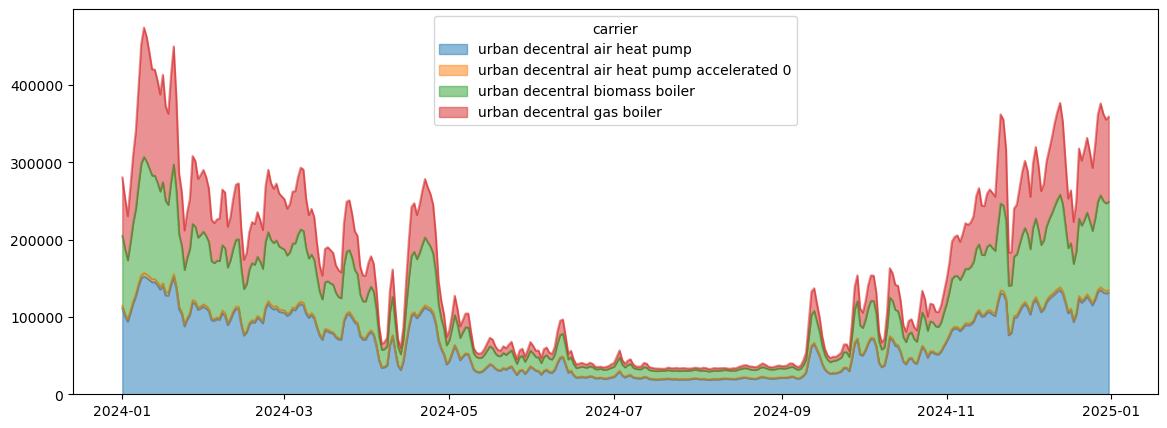

In [69]:
df = prepare_series(eb, mode='all')
df.index = df.index.get_level_values(1)
    
fig, ax = plt.subplots(figsize=(14, 5))

pos = df.T.clip(lower=0)
neg = df.T.clip(upper=0)

pos = pos.loc[:, pos.sum(axis=0) > pos.sum().sum() / 100]

pos.plot.area(ax=ax, stacked=True, alpha=0.5)
# neg.plot.area(ax=ax, stacked=True)

plt.show()

In [75]:
tss = []

for wiggle in [1500, 2000, 2500, 3000, 3500, 4000]:

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT_{}.nc'.format(wiggle)
    )

    # Get AC buses
    ac_buses = n.buses[n.buses.carrier == 'AC'].index

    # Get marginal prices for AC buses
    marginal_prices = n.buses_t.marginal_price[ac_buses]

    # Get withdrawals at those buses
    ss = n.statistics.withdrawal(groupby='bus').loc[idx['Link', :]]
    bus_withdrawals = ss.groupby(ss.index.str[:5]).sum().loc[ac_buses]

    # Calculate load-weighted average marginal prices
    wap = (marginal_prices * bus_withdrawals).sum(axis=1) / bus_withdrawals.sum()

    tss.append(wap.rename(wiggle))

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_1500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_3500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_4000.nc has buses, carriers, generators, global_constraints, lines

In [79]:
df = pd.concat(tss, axis=1)

In [80]:
df.head()

,1500,2000,2500,3000,3500,4000
snapshot,,,,,,
2024-01-01 00:00:00,1489.250274,120.636808,92.320871,59.859574,50.743068,50.743716
2024-01-01 03:00:00,1494.140679,120.973429,93.066118,59.861497,50.741505,50.742138
2024-01-01 06:00:00,1495.322907,122.205893,94.016928,59.763424,50.609561,50.610125
2024-01-01 09:00:00,1329.812575,95.744573,75.339827,46.098329,38.469000,38.470749
2024-01-01 12:00:00,1324.603866,94.136462,71.528882,43.053508,35.803929,35.804425


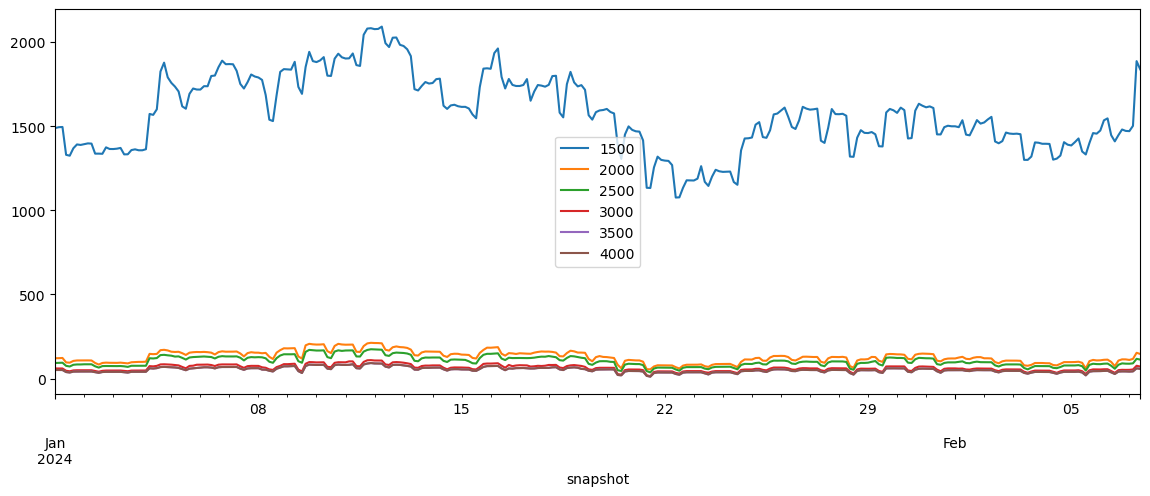

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

df.iloc[:300].plot(ax=ax)

ax.legend()
plt.show()

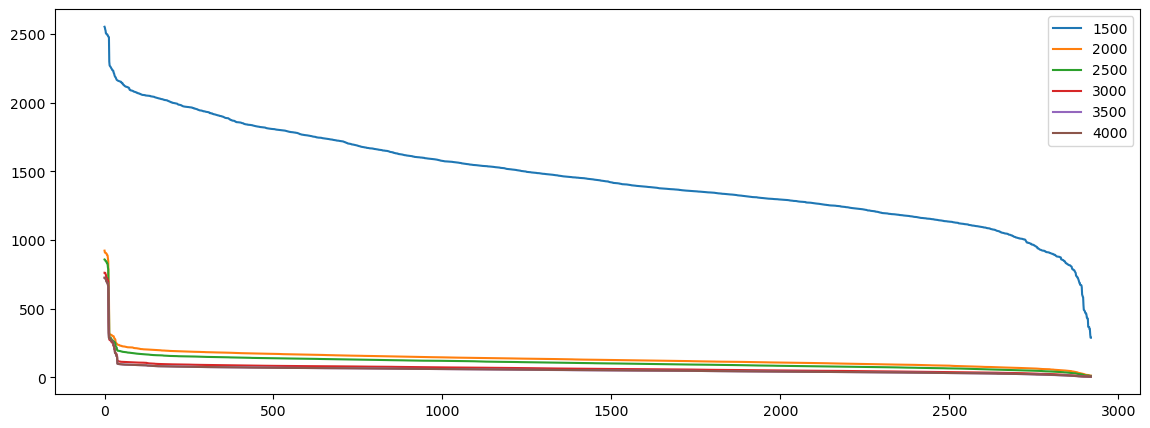

In [82]:
fig, ax = plt.subplots(figsize=(14, 5))

for col in df.columns:
    ax.plot(range(len(df[col])), df[col].sort_values(ascending=False), label=col)

ax.legend()
plt.show()

In [65]:
marginal_prices

Bus,AL0 0,AT0 0,BA0 0,BE0 0,BG0 0,CH0 0,CZ0 0,DE0 0,DE0 1,DE0 2,...,NL0 0,NO1 0,PL0 0,PT0 0,RO0 0,RS0 0,SE1 0,SI0 0,SK0 0,XK0 0
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,2191.617338,2154.532679,2188.126537,1047.433740,2193.489763,1929.255556,2401.081257,712.090030,1380.355547,605.870613,...,735.002632,715.027596,2088.449313,2191.407984,2191.348941,2192.481026,719.884223,2190.127583,2205.172372,2191.742647
2024-01-01 03:00:00,2191.615162,2154.532682,2188.126461,1047.471774,2193.489785,1929.255715,2401.078761,712.089322,1380.356020,605.870612,...,735.074441,715.027595,2118.043563,2191.407994,2191.348972,2192.480673,739.654279,2190.129920,2202.639685,2191.742726
2024-01-01 06:00:00,2191.553925,2154.532511,2188.126593,1047.471802,2193.489684,1929.255803,2401.078754,712.103589,1380.355752,605.870662,...,735.113227,715.027596,2122.359644,2191.408033,2191.348681,2192.481032,746.528008,2190.127537,2202.639522,2191.789585
2024-01-01 09:00:00,2164.434691,1839.259729,2186.964661,734.409790,2193.488736,1818.216992,2170.261560,712.088822,1134.087270,691.895584,...,734.372139,715.027596,2122.360854,1966.833055,2191.348483,2190.545704,746.402934,2092.110947,2169.533078,2200.566437
2024-01-01 12:00:00,2164.434156,1817.450609,2186.964670,734.409711,2193.489187,1693.454093,2170.261514,712.088839,1096.422075,691.895688,...,734.372068,715.027596,2124.287367,1966.832974,2191.348535,2193.991141,746.528130,2085.213087,2169.532985,2201.332218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 09:00:00,2157.965708,2118.329014,2188.373442,1293.200279,2192.873192,1951.976533,2306.001466,713.825385,1380.355356,718.214130,...,737.204096,715.027598,2065.615998,2191.407664,2191.348796,2192.480458,719.883576,2155.289266,2241.129976,2178.890339
2024-12-31 12:00:00,2157.965739,1972.426790,2188.128159,1068.652800,2193.487481,1747.313591,2306.001478,713.854876,1223.355698,716.647451,...,737.045873,715.027597,2071.341073,2191.407592,2191.348634,2196.943359,724.412233,2104.830407,2202.639725,2181.598826
2024-12-31 15:00:00,2198.575976,2196.273773,2256.007643,1097.444941,2216.976265,2026.706983,2401.078634,713.898870,1445.418722,633.052504,...,736.842855,715.027597,2071.341283,2191.407723,2220.712941,2260.321098,739.008246,2219.706730,2305.752362,2274.257798
